# Preprocess pipeline

## Imports 

In [1]:
import sys
import os
import yaml
import pandas as pd 


# Add src/ to sys.path so you can import batterydata
sys.path.append(os.path.abspath('../src'))

from batterydata.parsers.basytec_reader import BasyTecReader
from batterydata.pipeline.preprocessor import Preprocessor

### Load data

In [2]:
with open('../LCO_cells.yaml', 'r') as f:
    config = yaml.safe_load(f)
path = config['path_to_raw_data']
# read all LCO names and paths from the yaml file. this is the config file
#LCO_cells:
#  - name: LCO_cell_00000000001
#    path: 006_00000000001_LCO_Vamas_Test.txt

# read all LCO names and paths from the yaml file. this is the config file
LCO_cells = config['LCO_cells']
# create a list of tuples with (name, path) for each LCO cell
LCO_cells = [[cell['name'], os.path.join(path, cell['path'])] for cell in LCO_cells]
# create a list of tuples with (name, path) for each LCO cell






In [3]:

#for cell in LCO_cells:

# Load data
sample_name, file_path = LCO_cells[1]

reader = BasyTecReader(filepath=file_path, sample_id=sample_name)
result = reader.read()
df = result['data']


### preprocessing, cleaning and segmentation

#### helper functions : 

In [6]:
from typing import List, Dict

def pretty_print_blocks(blocks: List[Dict[str, object]]) -> None:
    """Print a readable summary of detected blocks.

    Parameters
    ----------
    blocks : list of dict
        Output from detect_repeating_blocks_with_steps() or find_repeating_blocks().
    """
    for b in blocks:
        step = b['start']
        if b['count'] > 1:
            print(f"Step {step}: {b['count']} x ({', '.join(b['block'])})")
        else:
            print(f"Step {step}: {', '.join(b['block'])}")


#### process

In [4]:
# Instantiate Preprocessor and process
preproc = Preprocessor(df, cell_capacity_ah=1.3)
seg, doe, blocks = preproc.process_with_blocks(min_block_len=4, max_block_len=4, min_repeats=2)
tables = preproc.export_tables()
segmented_df = tables["segmented_data"]
doe_table = tables["doe_table"]
metadata_table = tables["metadata"]

In [7]:
pretty_print_blocks(blocks)

Step 0: DIS_1.00_V3.0_noCV
Step 1: OCV_600
Step 2: 200 x (CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_noCV, OCV_10)
Step 802: DIS_1.00_V3.0_CV
Step 803: OCV_10
Step 804: CH_0.05_V4.2_noCV
Step 805: OCV_10
Step 806: DIS_0.05_V3.0_CV
Step 807: 158 x (OCV_10, CH_1.00_V4.2_CV, OCV_10, DIS_1.00_V3.0_noCV)
Step 1439: OCV_10
Step 1440: CH_1.00_V3.8_CV


#### select manually desired block to calculate KPIs 

In [8]:
# select a cycle : 
# from doe  teable, where block id = 2  
doe_cycle_df = doe[(doe['block_id']== 2 )]

# from segmented table select what was selected in deo table by step_number
raw_cycle_df = seg[(seg['step_number'].isin(doe_cycle_df['step_number'].tolist()))]

### Calculation of KPIs

In [9]:
from batterydata.pipeline.kpi_engine import *

In [10]:
kpis = [
    QChargeAh(), QDischargeAh(), EChargeWh(), EDischargeWh(),
    CoulombicEfficiency(), EnergyEfficiency(), VChargeAvg(), VDischargeAvg(),
    ChargeTotalDurationSeconds(), ChargeCVDurationSeconds(),
    ChargeCVTimeRatio(), ChargeCVCapacityRatio(), CCVTotalMismatchPct(),
    QChargeAhCV(), QChargeAhCC(), QChargeAhByCCCV(),   
]


# Table over all cycles present in DOE (single-block assumed)
kpi_table = compute_multi_cycle_kpi_table(
    raw_df=raw_cycle_df,
    doe_df=doe_cycle_df,
    kpi_units=kpis)


# Add retentions
kpi_table = add_capacity_retention(kpi_table, discharge_col="Q_discharge_Ah", block_col="block_id")
kpi_table = add_energy_retention(kpi_table, energy_col="E_discharge_Wh", block_col="block_id")



### Visualization 

#### helper functions 

In [13]:
# plot some of the KPIs 
# plot the following vs. Cycle number : 
# coulombic efficiency 
# Energy Efficiency 
# capacity retention 
# Energy retention 

# Then we will analyze the Constant voltage step : 
# Charge total duration 
# CV time ratio 
# Charge CV time ratio 



# --- KPI plotting helpers (Matplotlib only; one chart per function) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _cycle_col(df: pd.DataFrame) -> str:
    """Auto-pick the cycle column."""
    for c in ("cycle_number", "cycle_index"):
        if c in df.columns:
            return c
    raise KeyError("No 'cycle_number' or 'cycle_index' in KPI table.")

def _iter_blocks(df: pd.DataFrame):
    """Yield (label, frame) per block, else single ('All', df)."""
    if "block_id" in df.columns:
        for b, g in df.groupby("block_id", sort=True):
            yield str(b), g
    else:
        yield "All", df

def _line_plot(df: pd.DataFrame, x: str, y: str, title: str, ylabel: str, legend_title="block_id"):
    """Generic line plot with basic cleaning and sorting."""
    if y not in df.columns:
        raise KeyError(f"'{y}' not found in KPI table.")
    if x not in df.columns:
        raise KeyError(f"'{x}' not found in KPI table.")

    plt.figure(figsize=(7.5, 4.5))
    plt.ticklabel_format(useOffset=False, axis='both')  
    any_line = False
    for label, g in _iter_blocks(df):
        xv = pd.to_numeric(g[x], errors="coerce")
        yv = pd.to_numeric(g[y], errors="coerce")
        m = np.isfinite(xv) & np.isfinite(yv)
        if not m.any():
            continue
        xv = xv[m]
        yv = yv[m]
        order = np.argsort(xv.values)
        plt.plot(xv.iloc[order], yv.iloc[order], marker="o", linewidth=1.5, label=label)
        any_line = True

    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(ylabel)
    plt.grid(True, which="both", linestyle=":", linewidth=0.8)
    if any_line and "block_id" in df.columns:
        plt.legend(title=legend_title)
    plt.tight_layout()
    plt.show()

# =======================
# 1) Efficiency & Retention vs Cycle
# =======================

def plot_coulombic_efficiency(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "CoulombicEfficiency",
               title="Coulombic Efficiency vs Cycle",
               ylabel="Coulombic Efficiency [fraction]")

def plot_energy_efficiency(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "EnergyEfficiency",
               title="Energy Efficiency vs Cycle",
               ylabel="Energy Efficiency [fraction]")

def plot_capacity_retention(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "CapacityRetention_%",
               title="Capacity Retention vs Cycle",
               ylabel="Capacity Retention [%]")

def plot_energy_retention(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "EnergyRetention_%",
               title="Energy Retention vs Cycle",
               ylabel="Energy Retention [%]")

# =======================
# 2) CV step analysis vs Cycle
# =======================

def plot_charge_total_duration(kpi_table: pd.DataFrame, unit: str = "min") -> None:
    """
    Plot Charge_total_duration vs cycle.
    unit: 's' or 'min' (default).
    """
    if unit not in {"s", "min"}:
        raise ValueError("unit must be 's' or 'min'")
    base = "Charge_total_duration_s"
    if base not in kpi_table.columns:
        raise KeyError(f"'{base}' not found in KPI table.")

    df = kpi_table.copy()
    ycol = base
    ylabel = "Charge total duration [s]"
    if unit == "min":
        df["Charge_total_duration_min"] = pd.to_numeric(df[base], errors="coerce") / 60.0
        ycol = "Charge_total_duration_min"
        ylabel = "Charge total duration [min]"

    x = _cycle_col(df)
    _line_plot(df, x, ycol, title="Charge Total Duration vs Cycle", ylabel=ylabel)

def plot_cv_time_ratio(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "Charge_CV_time_ratio",
               title="Charge CV Time Ratio vs Cycle",
               ylabel="CV time ratio [fraction]")

def plot_cv_capacity_ratio(kpi_table: pd.DataFrame) -> None:
    x = _cycle_col(kpi_table)
    _line_plot(kpi_table, x, "Charge_CV_capacity_ratio",
               title="Charge CV Capacity Ratio vs Cycle",
               ylabel="CV capacity ratio [fraction]")






#### Visualization

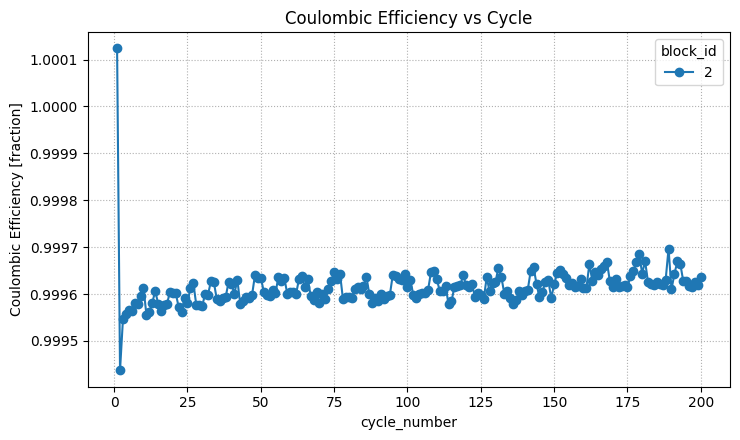

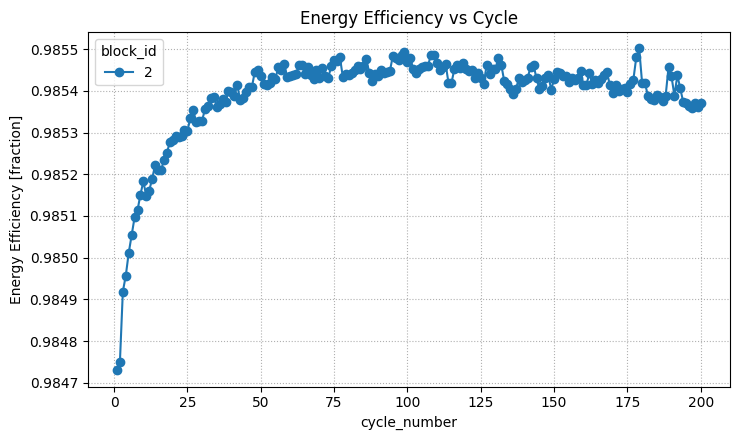

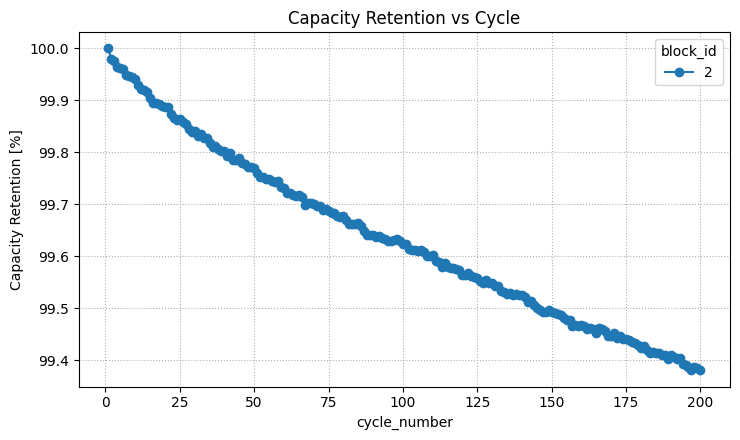

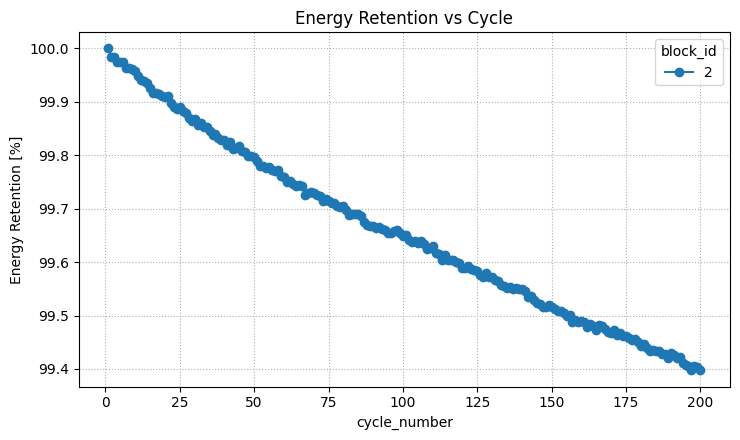

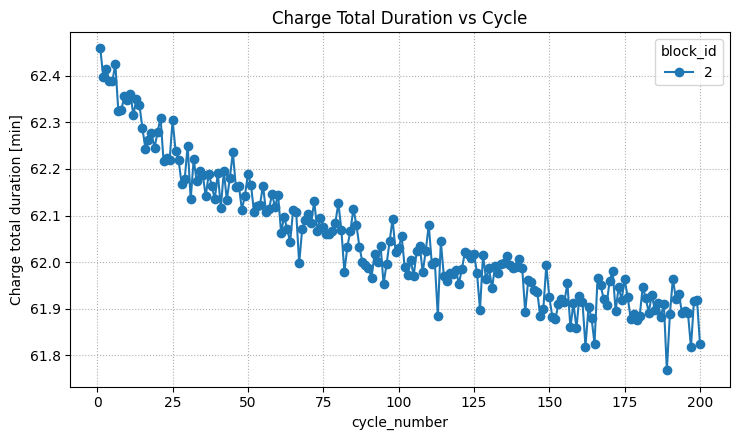

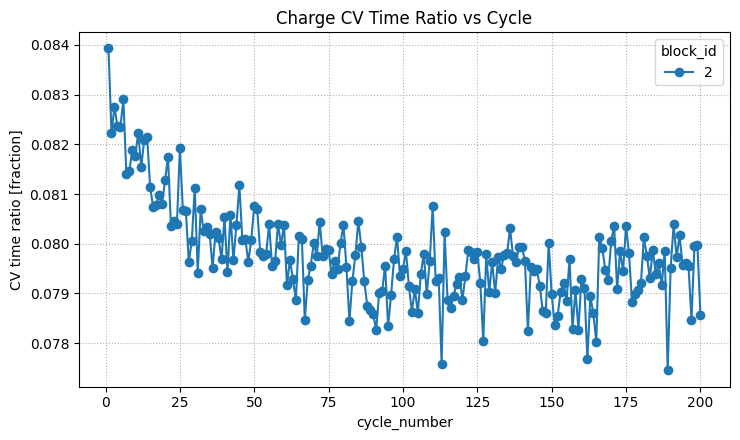

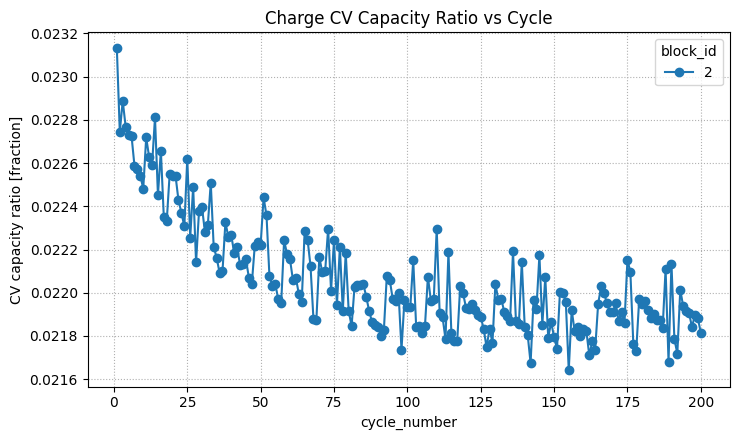

In [12]:
# -----------------------

plot_coulombic_efficiency(kpi_table)
plot_energy_efficiency(kpi_table)
plot_capacity_retention(kpi_table)
plot_energy_retention(kpi_table)
plot_charge_total_duration(kpi_table, unit="min")
plot_cv_time_ratio(kpi_table)
plot_cv_capacity_ratio(kpi_table)
# -----------------------